<a href="https://colab.research.google.com/github/pavlenkosasha/MillionaireAPI/blob/main/DS_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 1. Імпорт бібліотек

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

2. Завантаження даних

In [2]:
penguins = sns.load_dataset("penguins")

print("Перші 5 рядків:")
print(penguins.head())

print("\nІнформація:")
print(penguins.info())

Перші 5 рядків:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-

 3. Попередня обробка

In [18]:

# Видаляємо пропущені значення
penguins = penguins.dropna()

# Ознаки
X = penguins.drop("species", axis=1)

# Цільова змінна
y = penguins["species"]

# Які стовпці числові
numeric_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# Які категоріальні
categorical_features = [
    "island",
    "sex"
]

4. One-Hot Encoding + StandardScaler

In [19]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", StandardScaler(), numeric_features),

        ("cat", OneHotEncoder(), categorical_features)

    ]
)

 5. Поділ даних

In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)


 6. Pipeline

In [21]:
pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(random_state=42))

])

 7. Cross Validation

In [22]:
scores = cross_val_score(

    pipeline,
    X_train,
    y_train,
    cv=5

)

print("\nCross Validation Accuracy:")
print(scores)

print("Середня точність:", scores.mean())


Cross Validation Accuracy:
[1.         0.98113208 1.         1.         0.98113208]
Середня точність: 0.9924528301886791


 8. Навчання

In [23]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat', OneHotEncoder(),
                                                  ['island', 'sex'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

9. Перевірка на тестових даних

In [24]:

y_pred = pipeline.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



10. Grid Search

In [25]:
param_grid = {

    "classifier__n_estimators": [50,100,200],

    "classifier__max_depth":[None,5,10],

    "classifier__min_samples_split":[2,5]

}

grid = GridSearchCV(

    pipeline,

    param_grid,

    cv=5,

    scoring="accuracy"

)

grid.fit(X_train, y_train)

print("\nНайкращі параметри:")
print(grid.best_params_)

print("\nНайкраща Accuracy:")
print(grid.best_score_)


Найкращі параметри:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Найкраща Accuracy:
0.9962264150943396


11. Остаточна модель

In [26]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("\nФінальна Accuracy:")
print(accuracy_score(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))



Фінальна Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



12. Матриця помилок

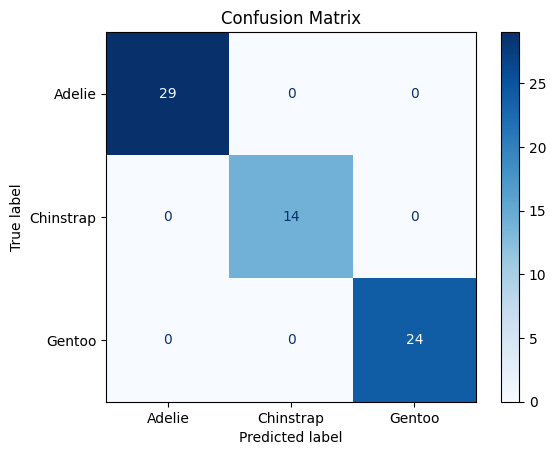

In [27]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=best_model.classes_

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()